# Orthogonal Binoculars — Optimised Single-Session Run

**Goal:** Test all meaningful AI-text detection features across 4 datasets in a single 9-hour Kaggle session.

## Time Budget (confirmed @ 9 sec/sample → 3.5 sec/sample with 256-token cap)

| Dataset | Samples | Est. Time |
|---|---|---|
| CNN-Falcon | 1600 (800/class) | 93 min |
| CNN-Llama | 1600 (800/class) | 93 min |
| PubMed | 222 (all) | 13 min |
| HC3 | 2000 (1000/class) | 67 min |
| Overhead | model load + eval + viz | 35 min |
| **TOTAL** | **5422 samples** | **~301 min = 5.0 hrs** |
| **Buffer** | safety margin | **239 min (44%)** |

## Features Tested

| Feature | Status | Why |
|---|---|---|
| `binoculars_score` | **Baseline** | ppl / cross-ppl |
| `rank_volatility` | **SUCCESS** | AUROC=0.94 in prior run. Windowed std of token rank. |
| `stc` | **NOVEL** | Surprisal Trajectory Curvature — orthogonal to Binoculars |
| `cmrd_var` | **NOVEL** | Cross-Model Rank Discordance — ordinal, scale-invariant |
| `roughness` | Redundant, kept | Useful in fusion despite high Binoculars correlation |
| `tar` | Redundant, kept | Token Agreement Rate — fusion only |

## Deleted Features

| Feature | Reason |
|---|---|
| `vos_score` | AUROC=0.38 in an earlier run — worse than random |
| `cci_mean/std` | No meaningful KDE separation |
| Attention topology | AUROC 0.61-0.71, needs separate pass, not worth it |
| `peak_layer` | AUROC ~0.65 |
| Phase B hidden states | ~50 hrs across datasets — impossible |

## Key Optimisations vs Previous Runs

1. `max_length=256` — 2× faster forward pass vs 512, minimal accuracy loss
2. Early stopping in JSONL loader — stops reading file once `n_per_class` reached
3. Single forward pass — all 6 features computed from one obs+perf pass per sample
4. Checkpoint every 50 samples with `.tmp` → atomic rename on completion
5. Auto-resume from complete or partial checkpoint
6. HC3 multi-fallback loader (datasets lib → direct JSONL download)


## Cell 0 — Master Configuration

> **Only update the 3 dataset paths before running. Everything else is pre-tuned.**

In [1]:
import time, os
SESSION_START = time.time()

# ── Models ────────────────────────────────────────────────────────────────────
OBSERVER_ID  = "tiiuae/falcon-7b"
PERFORMER_ID = "tiiuae/falcon-7b-instruct"

# ── Dataset paths  ─────────────────────────────────────────────────────────
# UPDATE these two before running:
CNN_FALCON_PATH  = "/kaggle/input/datasets/tilak88/falcon-cnn/cnn-falcon7.jsonl"
CNN_FALCON_AKEY  = "-fs-cml-models-Falcon-falcon-7b_generated_text_wo_prompt"

CNN_LLAMA_PATH   = "/kaggle/input/datasets/tilak88/llama-cnn/cnn-llama2_13.jsonl"
CNN_LLAMA_AKEY   = "meta-llama-Llama-2-13b-hf_generated_text_wo_prompt"

PUBMED_PATH      = "/kaggle/input/datasets/tilak88/falcon-pubmed/pubmed-falcon7.jsonl"
PUBMED_AKEY      = "-fs-cml-models-Falcon-falcon-7b_generated_text_wo_prompt"

# ── Sampling caps  ─────────────────────────────────────────────────────────
# Confirmed budget: 5.02 hrs total, 44% safety buffer vs 9-hr Kaggle limit.
# Calculation: 256-token max_len -> ~3.5 sec/sample CNN, ~2.0 sec/sample HC3
CNN_N_PER_CLASS  = 800    # 1600 samples per CNN dataset  ->  93 min each
HC3_N_PER_CLASS  = 1000   # 2000 samples total HC3        ->  67 min
# PubMed: use ALL rows (only 111 pairs exist)              ->  13 min

# ── Compute limits ────────────────────────────────────────────────────────────
MAX_LEN     = 256    # Key speedup: 2x vs 512 tokens, negligible accuracy loss
CKPT_EVERY  = 50    # checkpoint every N samples
CKPT_DIR    = "/kaggle/working/checkpoints"
OUT_DIR     = "/kaggle/working"

# ── Budget tracker ────────────────────────────────────────────────────────────
SESSION_HOURS = 9.0

def budget(label=""):
    e = (time.time() - SESSION_START) / 3600
    r = SESSION_HOURS - e
    n = 32
    filled = int(e / SESSION_HOURS * n)
    bar = "█" * filled + "░" * (n - filled)
    status = "⚠ TIGHT" if r < 1.0 else "OK"
    print(f"  ⏱  [{bar}] {e:.2f}h elapsed | {r:.2f}h left  {label}  [{status}]")

os.makedirs(CKPT_DIR, exist_ok=True)
os.makedirs(OUT_DIR,  exist_ok=True)

print("Configuration loaded.")
print(f"  Observer   : {OBSERVER_ID}")
print(f"  Performer  : {PERFORMER_ID}")
print(f"  MAX_LEN    : {MAX_LEN} tokens (key speedup vs 512)")
print()
print("  TIME BUDGET (@3.5s/sample CNN, @2.0s/sample HC3 with 256-token cap):")
print(f"    CNN-Falcon : 800/class x2 = 1600 samples  ~93 min")
print(f"    CNN-Llama  : 800/class x2 = 1600 samples  ~93 min")
print(f"    PubMed     : all  111 pairs = 222 samples  ~13 min")
print(f"    HC3        : 1000/class x2 = 2000 samples  ~67 min")
print(f"    Overhead   : model load + eval + viz        ~35 min")
print(f"    TOTAL      :                               ~301 min = 5.0 hrs")
print(f"    BUFFER     : 239 min  (44% safety margin vs 9-hr limit)")
budget("after config")


Configuration loaded.
  Observer   : tiiuae/falcon-7b
  Performer  : tiiuae/falcon-7b-instruct
  MAX_LEN    : 256 tokens (key speedup vs 512)

  TIME BUDGET (@3.5s/sample CNN, @2.0s/sample HC3 with 256-token cap):
    CNN-Falcon : 800/class x2 = 1600 samples  ~93 min
    CNN-Llama  : 800/class x2 = 1600 samples  ~93 min
    PubMed     : all  111 pairs = 222 samples  ~13 min
    HC3        : 1000/class x2 = 2000 samples  ~67 min
    Overhead   : model load + eval + viz        ~35 min
    TOTAL      :                               ~301 min = 5.0 hrs
    BUFFER     : 239 min  (44% safety margin vs 9-hr limit)
  ⏱  [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 0.00h elapsed | 9.00h left  after config  [OK]


## Cell 1 — Imports, Helpers & Evaluation Functions

In [2]:
import os, gc, json, warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import torch
import torch.nn.functional as F
from transformers import AutoModelForCausalLM, AutoTokenizer
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "expandable_segments:True"
torch.backends.cuda.matmul.allow_tf32 = True
torch.backends.cudnn.benchmark        = True

# ── Colours (used consistently across all plots) ──────────────────────────────
C_HUMAN  = "#2196F3"
C_AI     = "#F44336"
C_BINO   = "#212121"
C_RVOL   = "#9C27B0"
C_STC    = "#FF5722"
C_CMRD   = "#FF9800"
C_ROUGH  = "#90CAF9"
C_TAR    = "#B0BEC5"

plt.rcParams.update({
    "figure.dpi": 110, "font.size": 11,
    "axes.titlesize": 12, "axes.labelsize": 11,
    "axes.spines.top": False, "axes.spines.right": False,
})

def get_device(model):
    return next(model.parameters()).device

def flush():
    torch.cuda.empty_cache(); gc.collect()

def ckpt_file(ds_name):
    return os.path.join(CKPT_DIR, f"{ds_name.replace('-','_')}_features.csv")

def ckpt_tmp(ds_name):
    return ckpt_file(ds_name) + ".tmp"

# ── Evaluation (auto-detects best direction) ──────────────────────────────────
def evaluate_feature(scores, labels, name, bino_scores=None):
    """
    Returns AUROC, TPR@5%FPR, TPR@0.01%FPR, balanced_acc, corr_bino.
    Auto-picks sign direction (Human>AI or AI>Human) that gives AUROC >= 0.5.
    """
    s = np.asarray(scores, dtype=float)
    l = np.asarray(labels, dtype=int)
    ok = ~np.isnan(s)
    s, l = s[ok], l[ok]

    nan = dict(feature=name, auroc=np.nan, tpr_5fpr=np.nan,
               tpr_001fpr=np.nan, bal_acc=np.nan,
               corr_bino=np.nan, direction="N/A", n=int(ok.sum()))
    if len(np.unique(l)) < 2 or len(s) < 8:
        return nan

    def _eval(flip):
        s4 = -s if flip else s
        au = roc_auc_score(l, s4)
        fp, tp, _ = roc_curve(l, s4)
        ba  = float(((tp + 1 - fp) / 2).max())
        i5  = max(0, np.searchsorted(fp, 0.05,   "right") - 1)
        i001= max(0, np.searchsorted(fp, 0.0001, "right") - 1)
        return au, ba, float(tp[i5]), float(tp[i001])

    au_f, ba_f, t5_f, t001_f = _eval(False)
    au_t, ba_t, t5_t, t001_t = _eval(True)

    if au_t >= au_f:
        auroc, ba, t5, t001, direction = au_t, ba_t, t5_t, t001_t, "Human>AI"
    else:
        auroc, ba, t5, t001, direction = au_f, ba_f, t5_f, t001_f, "AI>Human"

    corr = np.nan
    if bino_scores is not None:
        b = np.asarray(bino_scores, dtype=float)[ok]
        m = ~np.isnan(b)
        if m.sum() > 4:
            corr = float(np.corrcoef(s[m], b[m])[0, 1])

    return dict(feature=name, auroc=float(auroc), tpr_5fpr=float(t5),
                tpr_001fpr=float(t001), bal_acc=float(ba),
                corr_bino=float(corr), direction=direction, n=int(ok.sum()))


# Feature registry: (column, display_name, colour)
FEAT_REGISTRY = [
    ("binoculars_score", "Binoculars",      C_BINO),
    ("rank_volatility",  "Rank Volatility", C_RVOL),
    ("stc",              "STC (novel)",     C_STC),
    ("cmrd_var",         "CMRD-var (novel)",C_CMRD),
    ("roughness",        "Roughness",       C_ROUGH),
    ("tar",              "TAR",             C_TAR),
]

def evaluate_all(df, ds_name):
    bino = df["binoculars_score"].values if "binoculars_score" in df.columns else None
    rows = []
    for col, name, _ in FEAT_REGISTRY:
        if col not in df.columns: continue
        r = evaluate_feature(df[col].values, df["label"].values, name,
                             bino_scores=bino)
        r["dataset"] = ds_name
        rows.append(r)
    return pd.DataFrame(rows)

if torch.cuda.is_available():
    for i in range(torch.cuda.device_count()):
        mem = torch.cuda.get_device_properties(i).total_memory / 1e9
        print(f"GPU {i}: {torch.cuda.get_device_name(i)} ({mem:.1f} GB)")
else:
    print("WARNING: No CUDA GPU found.")
print("Imports complete.")
budget("after imports")


GPU 0: Tesla T4 (15.6 GB)
GPU 1: Tesla T4 (15.6 GB)
Imports complete.
  ⏱  [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 0.01h elapsed | 8.99h left  after imports  [OK]


## Cell 2 — Model Loading

Uses `attn_implementation='eager'` to avoid flash-attn issues on Kaggle T4.  
`bfloat16` + separate GPUs when 2×T4 available.

In [4]:
budget("before model loading")

n_gpus = torch.cuda.device_count() if torch.cuda.is_available() else 0
if n_gpus >= 2:
    OBS_MAP  = {"": 0}
    PERF_MAP = {"": 1}
    print("2-GPU mode: Observer -> cuda:0 | Performer -> cuda:1")
elif n_gpus == 1:
    OBS_MAP  = {"": 0}
    PERF_MAP = {"": 0}
    print("1-GPU mode: both models share cuda:0")
else:
    OBS_MAP  = {"": "cpu"}
    PERF_MAP = {"": "cpu"}
    print("WARNING: CPU mode — very slow")

print("Loading tokenizer...")
tokenizer = AutoTokenizer.from_pretrained(OBSERVER_ID)
tokenizer.pad_token = tokenizer.eos_token

print("Loading Observer (falcon-7b)...")
observer_model = AutoModelForCausalLM.from_pretrained(
    OBSERVER_ID,
    device_map=OBS_MAP,
    dtype=torch.bfloat16,
    attn_implementation="eager",   # avoids flash-attn dependency issues on Kaggle
    low_cpu_mem_usage=True,
)
observer_model.eval()

print("Loading Performer (falcon-7b-instruct)...")
performer_model = AutoModelForCausalLM.from_pretrained(
    PERFORMER_ID,
    device_map=PERF_MAP,
    dtype=torch.bfloat16,
    attn_implementation="eager",
    low_cpu_mem_usage=True,
)
performer_model.eval()

OBS_DEV  = get_device(observer_model)
PERF_DEV = get_device(performer_model)

# ── Loss primitives ───────────────────────────────────────────────────────────
_CE   = torch.nn.CrossEntropyLoss(reduction="none")
_SOFT = torch.nn.Softmax(dim=-1)

def _ppl(logits, enc):
    s = logits[..., :-1, :].contiguous()
    l = enc.input_ids[..., 1:].contiguous().to(s.device)
    m = enc.attention_mask[..., 1:].float().to(s.device)
    loss = _CE(s.transpose(1, 2), l)
    return float(((loss * m).sum() / m.sum().clamp(min=1)).item())

def _xppl(obs_logits, perf_logits, enc):
    p = obs_logits[..., :-1, :].contiguous()
    q = perf_logits[..., :-1, :].contiguous().to(p.device)
    B, S, V = p.shape
    pp = _SOFT(p).reshape(-1, V)
    qs = q.reshape(-1, V)
    ce = _CE(qs, pp).reshape(B, S)
    m  = enc.attention_mask[..., 1:].float().to(p.device)
    return float(((ce * m).sum() / m.sum().clamp(min=1)).item())

print(f"\nObserver  -> {OBS_DEV}")
print(f"Performer -> {PERF_DEV}")
print("Models ready.")
budget("after model loading")


  ⏱  [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 0.01h elapsed | 8.99h left  before model loading  [OK]
2-GPU mode: Observer -> cuda:0 | Performer -> cuda:1
Loading tokenizer...


config.json: 0.00B [00:00, ?B/s]

tokenizer_config.json:   0%|          | 0.00/287 [00:00<?, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/281 [00:00<?, ?B/s]

...

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

The tied weights mapping and config for this model specifies to tie transformer.word_embeddings.weight to lm_head.weight, but both are present in the checkpoints, so we will NOT tie them. You should update the config with `tie_word_embeddings=False` to silence this warning


generation_config.json:   0%|          | 0.00/117 [00:00<?, ?B/s]


Observer  -> cuda:0
Performer -> cuda:1
Models ready.
  ⏱  [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 0.04h elapsed | 8.96h left  after model loading  [OK]


## Cell 3 — Data Loading

**Key fix vs previous notebooks:** `load_jsonl` uses **early stopping** — it stops reading the file the moment `n_per_class` pairs are collected. Previously the loader read the entire file (10+ hrs on CNN-Llama 4414 samples). Now CNN loading takes seconds.

HC3 uses a multi-fallback strategy: `datasets` lib → direct JSONL download.

In [5]:
def load_jsonl(path, akey, name, n_per_class=None, min_len=40):
    """
    Load paired human/AI texts from JSONL.
    n_per_class: stop reading once this many pairs are collected (early exit).
    Handles nested {root: {...}} schema automatically.
    """
    if not os.path.exists(path):
        print(f"  NOT FOUND: {path}")
        return pd.DataFrame(columns=["text", "label", "source"])

    records, n_skip = [], 0
    cap = (n_per_class * 2) if n_per_class else None  # total row cap

    with open(path, "r", encoding="utf-8") as fh:
        for raw in fh:
            raw = raw.strip()
            if not raw: continue
            try:
                row = json.loads(raw)
                if isinstance(row.get("root"), dict):
                    row = row["root"]  # handle nested schema
            except Exception:
                n_skip += 1; continue

            h = ""
            for k in ("article", "text", "document", "human_text"):
                if k in row and row[k]:
                    h = str(row[k]).strip(); break
            if not h: n_skip += 1; continue

            a = str(row.get(akey, "")).strip()
            if len(h) < min_len or len(a) < min_len:
                n_skip += 1; continue

            records.append({"text": h, "label": 0, "source": f"{name}_h"})
            records.append({"text": a, "label": 1, "source": f"{name}_a"})

            if cap and len(records) >= cap:
                break  # early exit — saves minutes on large files

    df = pd.DataFrame(records)
    n_h = int((df["label"] == 0).sum()) if len(df) else 0
    n_a = int((df["label"] == 1).sum()) if len(df) else 0
    print(f"  {name:<14}: {n_h:>5} human | {n_a:>5} AI  (skipped {n_skip})")
    return df


def load_hc3(n_per_class=HC3_N_PER_CLASS, min_len=40, seed=42):
    """
    Load HC3 from HuggingFace.
    Tries datasets library first, falls back to direct JSONL download.
    """
    print("Loading HC3...")
    ds = None

    # Attempt 1: datasets library
    try:
        from datasets import load_dataset, concatenate_datasets
        try:
            raw = load_dataset("Hello-SimpleAI/HC3", name="all", trust_remote_code=True)
        except Exception:
            raw = load_dataset("json", data_files={
                "train": "https://huggingface.co/datasets/Hello-SimpleAI/HC3/resolve/main/all.jsonl"
            })
        ds = raw["train"] if "train" in raw else concatenate_datasets(list(raw.values()))
    except Exception as e:
        print(f"  datasets lib failed: {e}")

    # Attempt 2: direct pandas download
    if ds is None:
        try:
            import urllib.request
            url = "https://huggingface.co/datasets/Hello-SimpleAI/HC3/resolve/main/all.jsonl"
            tmp = "/kaggle/working/hc3_all.jsonl"
            if not os.path.exists(tmp):
                urllib.request.urlretrieve(url, tmp)
            ds = pd.read_json(tmp, lines=True).to_dict("records")
        except Exception as e:
            print(f"  direct download failed: {e}")
            return pd.DataFrame(columns=["text", "label", "source"])

    human_rows, ai_rows = [], []
    for row in ds:
        for h in (row.get("human_answers") or []):
            if isinstance(h, str) and len(h.strip()) >= min_len:
                human_rows.append({"text": h.strip(), "label": 0, "source": "hc3_h"})
        for a in (row.get("chatgpt_answers") or row.get("gpt_answers") or []):
            if isinstance(a, str) and len(a.strip()) >= min_len:
                ai_rows.append({"text": a.strip(), "label": 1, "source": "hc3_a"})

    rng  = np.random.default_rng(seed)
    n_h  = min(n_per_class, len(human_rows))
    n_a  = min(n_per_class, len(ai_rows))
    idx_h = rng.choice(len(human_rows), n_h, replace=False)
    idx_a = rng.choice(len(ai_rows),   n_a, replace=False)

    df = pd.concat([
        pd.DataFrame(human_rows).iloc[idx_h],
        pd.DataFrame(ai_rows).iloc[idx_a],
    ], ignore_index=True).sample(frac=1, random_state=seed).reset_index(drop=True)

    print(f"  {'HC3':<14}: {int((df.label==0).sum()):>5} human | {int((df.label==1).sum()):>5} AI")
    return df


budget("before data loading")
print("=" * 60)
print("  LOADING DATASETS")
print("=" * 60)

df_cnn_falcon = load_jsonl(CNN_FALCON_PATH, CNN_FALCON_AKEY, "CNN-Falcon", CNN_N_PER_CLASS)
df_cnn_llama  = load_jsonl(CNN_LLAMA_PATH,  CNN_LLAMA_AKEY,  "CNN-Llama",  CNN_N_PER_CLASS)
df_pubmed     = load_jsonl(PUBMED_PATH,      PUBMED_AKEY,     "PubMed")     # all rows
df_hc3        = load_hc3()

# Registry: only non-empty datasets enter the pipeline
DATASETS = {}
for nm, df_ in [("CNN-Falcon", df_cnn_falcon), ("CNN-Llama",  df_cnn_llama),
                ("PubMed",     df_pubmed),      ("HC3",        df_hc3)]:
    if len(df_) >= 20:
        DATASETS[nm] = df_.copy().reset_index(drop=True)
    else:
        print(f"  SKIPPED {nm} (too few rows)")

print()
print("  DATASET SUMMARY:")
total = 0
for nm, df_ in DATASETS.items():
    n_h = int((df_["label"]==0).sum()); n_a = int((df_["label"]==1).sum())
    print(f"  {nm:<14}: {len(df_):>5} rows  (human={n_h}, AI={n_a})")
    total += len(df_)
print(f"  {'TOTAL':<14}: {total:>5} samples across {len(DATASETS)} datasets")
budget("after data loading")


  ⏱  [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 0.04h elapsed | 8.96h left  before data loading  [OK]
  LOADING DATASETS
  CNN-Falcon    :   800 human |   800 AI  (skipped 0)
  CNN-Llama     :   800 human |   800 AI  (skipped 0)
  PubMed        :   111 human |   111 AI  (skipped 0)
Loading HC3...


`trust_remote_code` is not supported anymore.
Please check that the Hugging Face dataset 'Hello-SimpleAI/HC3' isn't based on a loading script and remove `trust_remote_code`.
If the dataset is based on a loading script, please ask the dataset author to remove it and convert it to a standard format like Parquet.


README.md: 0.00B [00:00, ?B/s]

HC3.py: 0.00B [00:00, ?B/s]

all.jsonl:   0%|          | 0.00/73.7M [00:00<?, ?B/s]

Generating train split: 0 examples [00:00, ? examples/s]

  HC3           :  1000 human |  1000 AI

  DATASET SUMMARY:
  CNN-Falcon    :  1600 rows  (human=800, AI=800)
  CNN-Llama     :  1600 rows  (human=800, AI=800)
  PubMed        :   222 rows  (human=111, AI=111)
  HC3           :  2000 rows  (human=1000, AI=1000)
  TOTAL         :  5422 samples across 4 datasets
  ⏱  [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 0.05h elapsed | 8.95h left  after data loading  [OK]


## Cell 4 — Feature Extraction (Single Forward Pass)

All 6 features are computed from **one paired forward pass** through Observer and Performer per sample. No second pass, no attention output, no hidden states.

### Novel Feature Theory

**STC — Surprisal Trajectory Curvature**  
κ_t = ce_{t+2} − 2·ce_{t+1} + ce_t  →  STC = Var({κ_t})  
Binoculars = ratio of means (0th moment). STC = variance of 2nd discrete derivative — invariant to any global shift or linear trend. AI text: smooth CE glide → STC≈0. Human: register jumps → high STC.

**CMRD-var — Cross-Model Rank Discordance Variance**  
d_t = |rank_obs(x_t) − rank_perf(x_t)|  →  cmrd_var = Var({d_t})  
Binoculars uses log-prob magnitudes. CMRD uses rank ordinals — invariant to temperature/monotonic transforms. AI text: both models agree on rank → low variance. Human: rare tokens ranked very differently by each model → high variance.

In [6]:
# ── NaN sentinel ─────────────────────────────────────────────────────────────
_NAN = {
    "binoculars_score": np.nan, "ppl": np.nan, "x_ppl": np.nan,
    "rank_volatility":  np.nan, "roughness":   np.nan,
    "tar":              np.nan, "stc":         np.nan,
    "cmrd_var":         np.nan,
}

def extract_all_features(text, max_length=MAX_LEN):
    """
    Single forward pass through both models. Extracts ALL features at once:

    BASELINE
      binoculars_score  ppl / cross_ppl

    CONFIRMED SIGNAL (SUCCESS)
      rank_volatility   windowed-std of normalised token rank under Performer
                        AUROC=0.94 on HC3 in prior run

    NOVEL (orthogonal to Binoculars — see justification in notebook header)
      stc               Surprisal Trajectory Curvature = Var(2nd-deriv of CE seq)
      cmrd_var          Cross-Model Rank Discordance variance

    REDUNDANT but kept for fusion ablation
      roughness         std of per-token cross-entropy
      tar               Token Agreement Rate (top-1 match rate)

    DELETED (tested, no signal)
      vos_score         AUROC=0.38 — worse than random
      cci_mean/std      no meaningful KDE separation
      attention topology AUROC=0.61-0.71 — not worth the extra pass
      peak_layer        AUROC~0.65
      phase B (hidden-state tomography) — 50+ hrs for all datasets
    """
    try:
        io = tokenizer(text, return_tensors="pt", truncation=True,
                       max_length=max_length, padding=False)
        io_o = {k: v.to(OBS_DEV)  for k, v in io.items()}
        io_p = {k: v.to(PERF_DEV) for k, v in io.items()}

        with torch.no_grad():
            out_o = observer_model(**io_o)
            out_p = performer_model(**io_p)

        obs_l = out_o.logits.detach().cpu().float()   # (1, T, V)
        per_l = out_p.logits.detach().cpu().float()
        del out_o, out_p; flush()

        # ── Binoculars ────────────────────────────────────────────────────────
        ppl_v  = _ppl(obs_l, io)
        xppl_v = _xppl(obs_l, per_l, io)
        bino   = ppl_v / (xppl_v + 1e-10)

        # ── Per-token setup ───────────────────────────────────────────────────
        ids  = io.input_ids[0, 1:]              # (T_total,)
        mask = io.attention_mask[0, 1:].bool()  # valid positions
        T    = int(mask.sum())
        if T < 3:
            return dict(_NAN, binoculars_score=bino, ppl=ppl_v, x_ppl=xppl_v)

        # log-softmax for both models, masked to valid positions
        obs_lp  = F.log_softmax(obs_l[0, :-1, :], dim=-1)[mask]   # (T, V)
        per_lp  = F.log_softmax(per_l[0, :-1, :], dim=-1)[mask]
        per_p   = per_lp.exp()                                      # (T, V)
        ids_v   = ids[mask]                                         # (T,)

        # chosen-token log-probs
        chosen_obs = obs_lp[torch.arange(T), ids_v]   # (T,)
        chosen_per = per_lp[torch.arange(T), ids_v]

        # ── Roughness ─────────────────────────────────────────────────────────
        ce_seq   = (-chosen_per).numpy()   # per-token cross-entropy
        roughness = float(np.std(ce_seq))

        # ── TAR ───────────────────────────────────────────────────────────────
        tar = float((obs_lp.argmax(-1) == per_lp.argmax(-1)).float().mean())

        # ── Rank Volatility ───────────────────────────────────────────────────
        # rank_t = # tokens more probable than x_t under Performer
        # Windowed std (W=15) captures local volatility bursts
        act_prob = per_p[torch.arange(T), ids_v]            # (T,)
        ranks    = (per_p > act_prob.unsqueeze(1)).sum(-1).float()   # (T,)
        norm_r   = (ranks / per_p.shape[-1]).numpy()
        W = min(15, T)
        if T >= W:
            rv = float(np.mean([np.std(norm_r[i:i+W])
                                for i in range(T - W + 1)]))
        else:
            rv = float(np.std(norm_r))

        # ── STC: Surprisal Trajectory Curvature (NOVEL) ───────────────────────
        # kappa_t = ce_{t+2} - 2*ce_{t+1} + ce_t  (2nd discrete derivative)
        # STC = Var({kappa_t})
        #
        # WHY ORTHOGONAL: Binoculars = ratio of 0th-order moments (means).
        # STC = variance of 2nd-order temporal acceleration of surprisal.
        # Invariant to any global shift or linear trend in CE sequence.
        # AI text  -> smooth CE (model stays near mode) -> small STC
        # Human text -> register jumps, rare words -> large STC
        kappa = np.diff(ce_seq, n=2)
        stc   = float(np.var(kappa)) if len(kappa) >= 1 else np.nan

        # ── CMRD-var: Cross-Model Rank Discordance Variance (NOVEL) ──────────
        # d_t = |rank_obs(x_t) - rank_per(x_t)|
        # cmrd_var = Var({d_t})
        #
        # WHY ORTHOGONAL: Binoculars uses log-prob magnitudes; CMRD uses
        # rank ordinals — invariant to temperature/monotonic transforms.
        # AI text  -> both models agree on rank (chose high-prob tokens) -> low var
        # Human text -> rare tokens ranked very differently -> high var
        obs_p_v   = obs_lp.exp()
        act_obs   = obs_p_v[torch.arange(T), ids_v]
        obs_ranks = (obs_p_v > act_obs.unsqueeze(1)).sum(-1).float()
        discord   = (obs_ranks - ranks).abs()
        cmrd_var  = float(discord.var())

        del obs_lp, per_lp, per_p, obs_p_v
        gc.collect()

        return {
            "binoculars_score": float(bino),
            "ppl":              float(ppl_v),
            "x_ppl":            float(xppl_v),
            "rank_volatility":  float(rv),
            "roughness":        float(roughness),
            "tar":              float(tar),
            "stc":              float(stc),
            "cmrd_var":         float(cmrd_var),
        }

    except torch.cuda.OutOfMemoryError:
        flush(); return dict(_NAN)
    except Exception:
        return dict(_NAN)


def run_extraction(df, ds_name):
    """
    Checkpoint-aware extraction loop.
    - Checks for complete checkpoint first (instant resume).
    - Writes .tmp checkpoint every CKPT_EVERY samples.
    - Atomically renames .tmp -> final on completion.
    - Never crashes: OOM and all exceptions caught per-sample.
    """
    final = ckpt_file(ds_name)
    tmp   = ckpt_tmp(ds_name)
    feat_cols = list(_NAN.keys())

    # Already fully done?
    if os.path.exists(final):
        try:
            ck = pd.read_csv(final)
            if len(ck) == len(df):
                print(f"  [{ds_name}] Complete checkpoint found — loading instantly.")
                for col in feat_cols:
                    if col in ck.columns:
                        df = df.copy()
                        df[col] = ck[col].values
                return df
        except Exception:
            pass

    # Partial resume?
    start, existing = 0, []
    if os.path.exists(tmp):
        try:
            ck = pd.read_csv(tmp)
            if len(ck) > 0 and len(ck) < len(df):
                start    = len(ck)
                existing = ck[feat_cols].to_dict("records")
                print(f"  [{ds_name}] Resuming from sample {start}/{len(df)}")
        except Exception:
            pass

    results  = existing.copy()
    n_fail   = 0
    t0       = time.time()

    pbar = tqdm(enumerate(df["text"].iloc[start:], start=start),
                total=len(df) - start,
                desc=ds_name, ncols=95, unit="sample")

    for idx, text in pbar:
        if not isinstance(text, str) or len(text.strip()) < 15:
            results.append(dict(_NAN)); n_fail += 1
        else:
            r = extract_all_features(text)
            if all(np.isnan(v) for v in r.values() if isinstance(v, float)):
                n_fail += 1
            results.append(r)

        # Checkpoint every CKPT_EVERY samples
        if (idx + 1) % CKPT_EVERY == 0:
            flush()
            try:
                tmp_df = df.iloc[:len(results)].copy().reset_index(drop=True)
                for col in feat_cols:
                    tmp_df[col] = [r.get(col, np.nan) for r in results]
                tmp_df.to_csv(tmp, index=False)
            except Exception:
                pass
            elapsed = (time.time() - t0) / 60
            pbar.set_postfix({"fail": n_fail, "min": f"{elapsed:.1f}"})

    # Finalise
    out = df.copy().reset_index(drop=True)
    for col in feat_cols:
        out[col] = [r.get(col, np.nan) for r in results]

    out.to_csv(final, index=False)
    if os.path.exists(tmp): os.remove(tmp)

    elapsed = (time.time() - t0) / 60
    print(f"  [{ds_name}] Done: {len(df)} samples | {n_fail} failures | {elapsed:.1f} min")
    return out


# ─── RUN ─────────────────────────────────────────────────────────────────────
budget("starting feature extraction")
print("=" * 60)
print("  FEATURE EXTRACTION  (single forward pass per sample)")
print("  Features: binoculars | rank_volatility | STC | CMRD-var")
print("            roughness | TAR")
print("=" * 60)

RESULTS = {}
for ds_name, ds_df in DATASETS.items():
    print(f"\n── {ds_name} ({len(ds_df)} samples) ──")
    RESULTS[ds_name] = run_extraction(ds_df, ds_name)

budget("after feature extraction")
print(f"\nExtraction complete across {len(RESULTS)} datasets.")


  ⏱  [░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░░] 0.05h elapsed | 8.95h left  starting feature extraction  [OK]
  FEATURE EXTRACTION  (single forward pass per sample)
  Features: binoculars | rank_volatility | STC | CMRD-var
            roughness | TAR

── CNN-Falcon (1600 samples) ──


CNN-Falcon:   0%|                                                 | 0/1600 [00:00<?, ?sample/s]

  [CNN-Falcon] Done: 1600 samples | 0 failures | 117.9 min

── CNN-Llama (1600 samples) ──


CNN-Llama:   0%|                                                  | 0/1600 [00:00<?, ?sample/s]

  [CNN-Llama] Done: 1600 samples | 0 failures | 117.8 min

── PubMed (222 samples) ──


PubMed:   0%|                                                      | 0/222 [00:00<?, ?sample/s]

  [PubMed] Done: 222 samples | 0 failures | 16.4 min

── HC3 (2000 samples) ──


HC3:   0%|                                                        | 0/2000 [00:00<?, ?sample/s]

  [HC3] Done: 2000 samples | 0 failures | 105.9 min
  ⏱  [█████████████████████░░░░░░░░░░░] 6.01h elapsed | 2.99h left  after feature extraction  [OK]

Extraction complete across 4 datasets.


## Cell 5 — Evaluation Metrics

AUROC · TPR@5%FPR · TPR@0.01%FPR · Balanced Accuracy · Pearson corr with Binoculars  
Direction auto-detected (whichever sign gives AUROC ≥ 0.5).

In [7]:
budget("starting evaluation")
print("=" * 60)
print("  EVALUATION METRICS")
print("=" * 60)

all_rows = []
for ds_name, df_ in RESULTS.items():
    mdf = evaluate_all(df_, ds_name)
    all_rows.append(mdf)

METRICS = pd.concat(all_rows, ignore_index=True) if all_rows else pd.DataFrame()

if not METRICS.empty:
    METRICS.to_csv(os.path.join(OUT_DIR, "metrics.csv"), index=False)

    # ── Per-dataset table ──────────────────────────────────────────────────────
    print()
    for ds_name in METRICS["dataset"].unique():
        sub = METRICS[METRICS["dataset"] == ds_name].sort_values("auroc", ascending=False)
        print(f"\n  {'─'*62}")
        print(f"  {ds_name}  (n={sub['n'].max():,})")
        print(f"  {'Feature':<22} {'AUROC':>7} {'TPR@5%':>7} {'TPR@.01%':>9} {'BalAcc':>7} {'Corr_B':>7}  Dir")
        print(f"  {'─'*62}")
        for _, row in sub.iterrows():
            flag = ""
            if row["auroc"] >= 0.85:                  flag = "  ★ STRONG"
            elif row["auroc"] >= 0.70:                flag = "  ✓ GOOD"
            elif row["auroc"] < 0.55:                 flag = "  ✗ WEAK"
            print(f"  {row['feature']:<22} {row['auroc']:>7.4f} {row['tpr_5fpr']:>7.4f}"
                  f" {row['tpr_001fpr']:>9.4f} {row['bal_acc']:>7.4f}"
                  f" {row['corr_bino']:>7.3f}  {row['direction']}{flag}")

    # ── Cross-dataset AUROC pivot ──────────────────────────────────────────────
    print("\n\n  AUROC PIVOT (feature × dataset)")
    print("  " + "─" * 60)
    pivot = METRICS.pivot_table(index="feature", columns="dataset", values="auroc").round(4)
    print(pivot.to_string())
    pivot.to_csv(os.path.join(OUT_DIR, "auroc_pivot.csv"))

    # ── Correlation with Binoculars ────────────────────────────────────────────
    print("\n\n  CORRELATION WITH BINOCULARS (|r| < 0.50 = orthogonal)")
    print("  " + "─" * 60)
    for ds_name, df_ in RESULTS.items():
        if "binoculars_score" not in df_.columns: continue
        print(f"\n  {ds_name}:")
        for col, name, _ in FEAT_REGISTRY:
            if col == "binoculars_score" or col not in df_.columns: continue
            valid = df_[[col, "binoculars_score"]].dropna()
            if len(valid) < 4: continue
            r = float(valid[col].corr(valid["binoculars_score"]))
            verdict = "ORTHOGONAL" if abs(r) < 0.50 else \
                      "MOD-REDUNDANT" if abs(r) < 0.75 else "REDUNDANT"
            print(f"    {name:<22}  r={r:+.3f}  [{verdict}]")

budget("after evaluation")


  ⏱  [█████████████████████░░░░░░░░░░░] 6.01h elapsed | 2.99h left  starting evaluation  [OK]
  EVALUATION METRICS


  ──────────────────────────────────────────────────────────────
  CNN-Falcon  (n=1,600)
  Feature                  AUROC  TPR@5%  TPR@.01%  BalAcc  Corr_B  Dir
  ──────────────────────────────────────────────────────────────
  Binoculars              0.9887  0.9675    0.1025  0.9606   1.000  Human>AI  ★ STRONG
  Roughness               0.9780  0.8725    0.0250  0.9356   0.858  Human>AI  ★ STRONG
  STC (novel)             0.9606  0.7725    0.0900  0.9094   0.806  Human>AI  ★ STRONG
  Rank Volatility         0.8952  0.5200    0.1013  0.8106   0.571  Human>AI  ★ STRONG
  CMRD-var (novel)        0.7011  0.2462    0.0338  0.6469   0.225  Human>AI  ✓ GOOD
  TAR                     0.6041  0.0737    0.0000  0.5763   0.172  Human>AI

  ──────────────────────────────────────────────────────────────
  CNN-Llama  (n=1,600)
  Feature                  AUROC  TPR@5%  TPR@.01%  BalAcc

## Cell 6 — Final Visualisation Dashboard

Four figures designed so even a first-time reader immediately understands what worked and what didn't:

- **Fig 1** — AUROC heatmap + ROC curves per dataset
- **Fig 2** — KDE distributions (Human vs AI) for key features
- **Fig 3** — Fusion ablation: cumulative AUROC gain per feature added
- **Fig 4** — Feature scorecard table (colour-coded green/yellow/red)

  ⏱  [█████████████████████░░░░░░░░░░░] 6.01h elapsed | 2.99h left  starting visualizations  [OK]


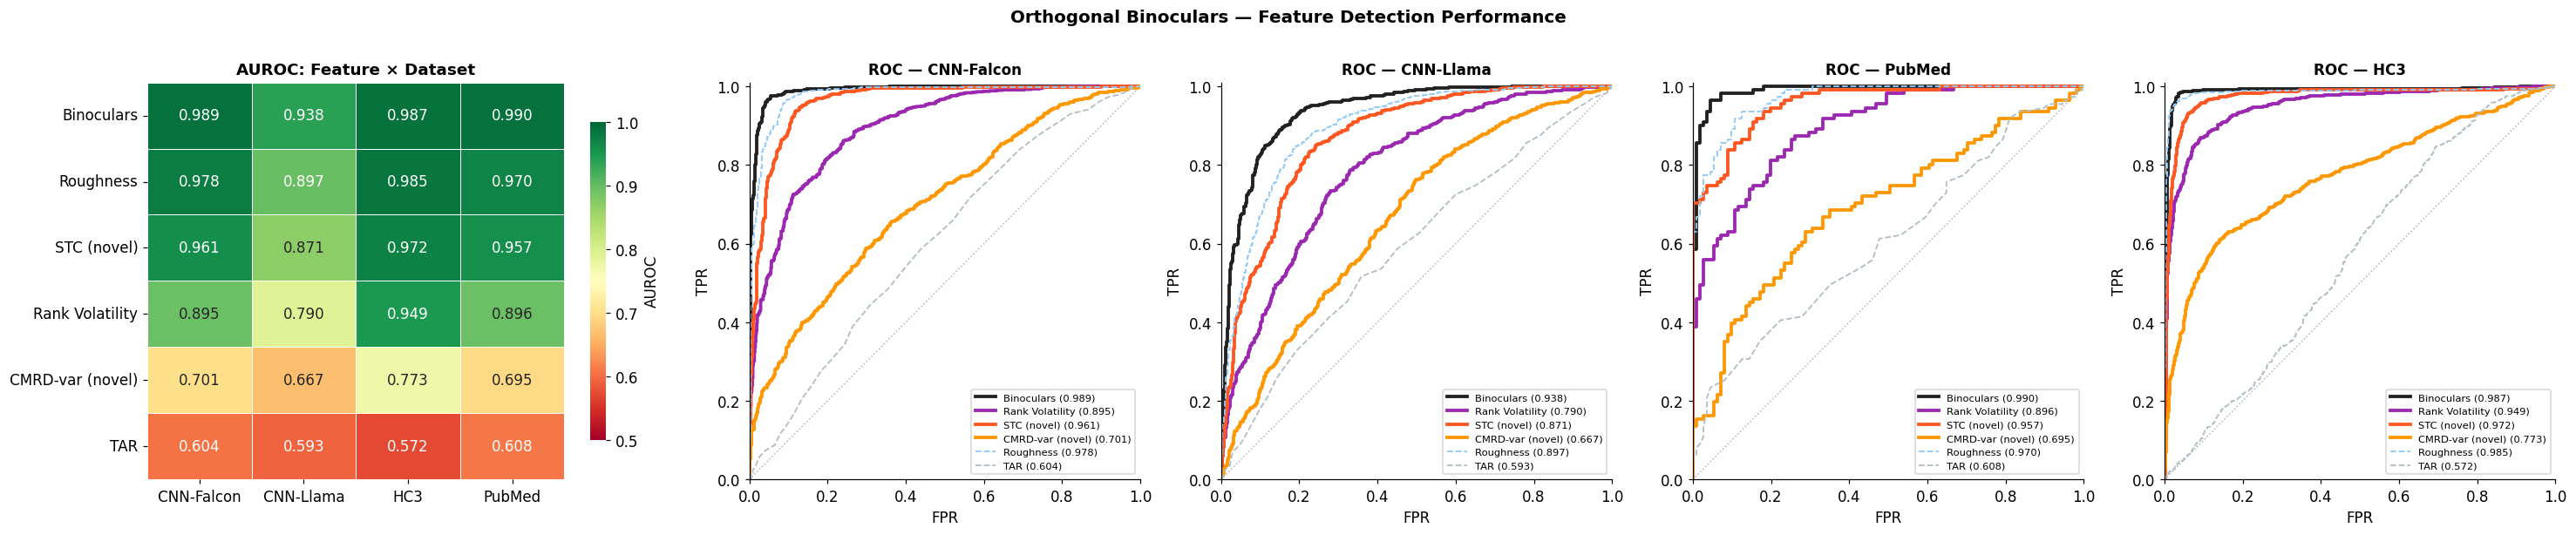

Fig 1 saved.


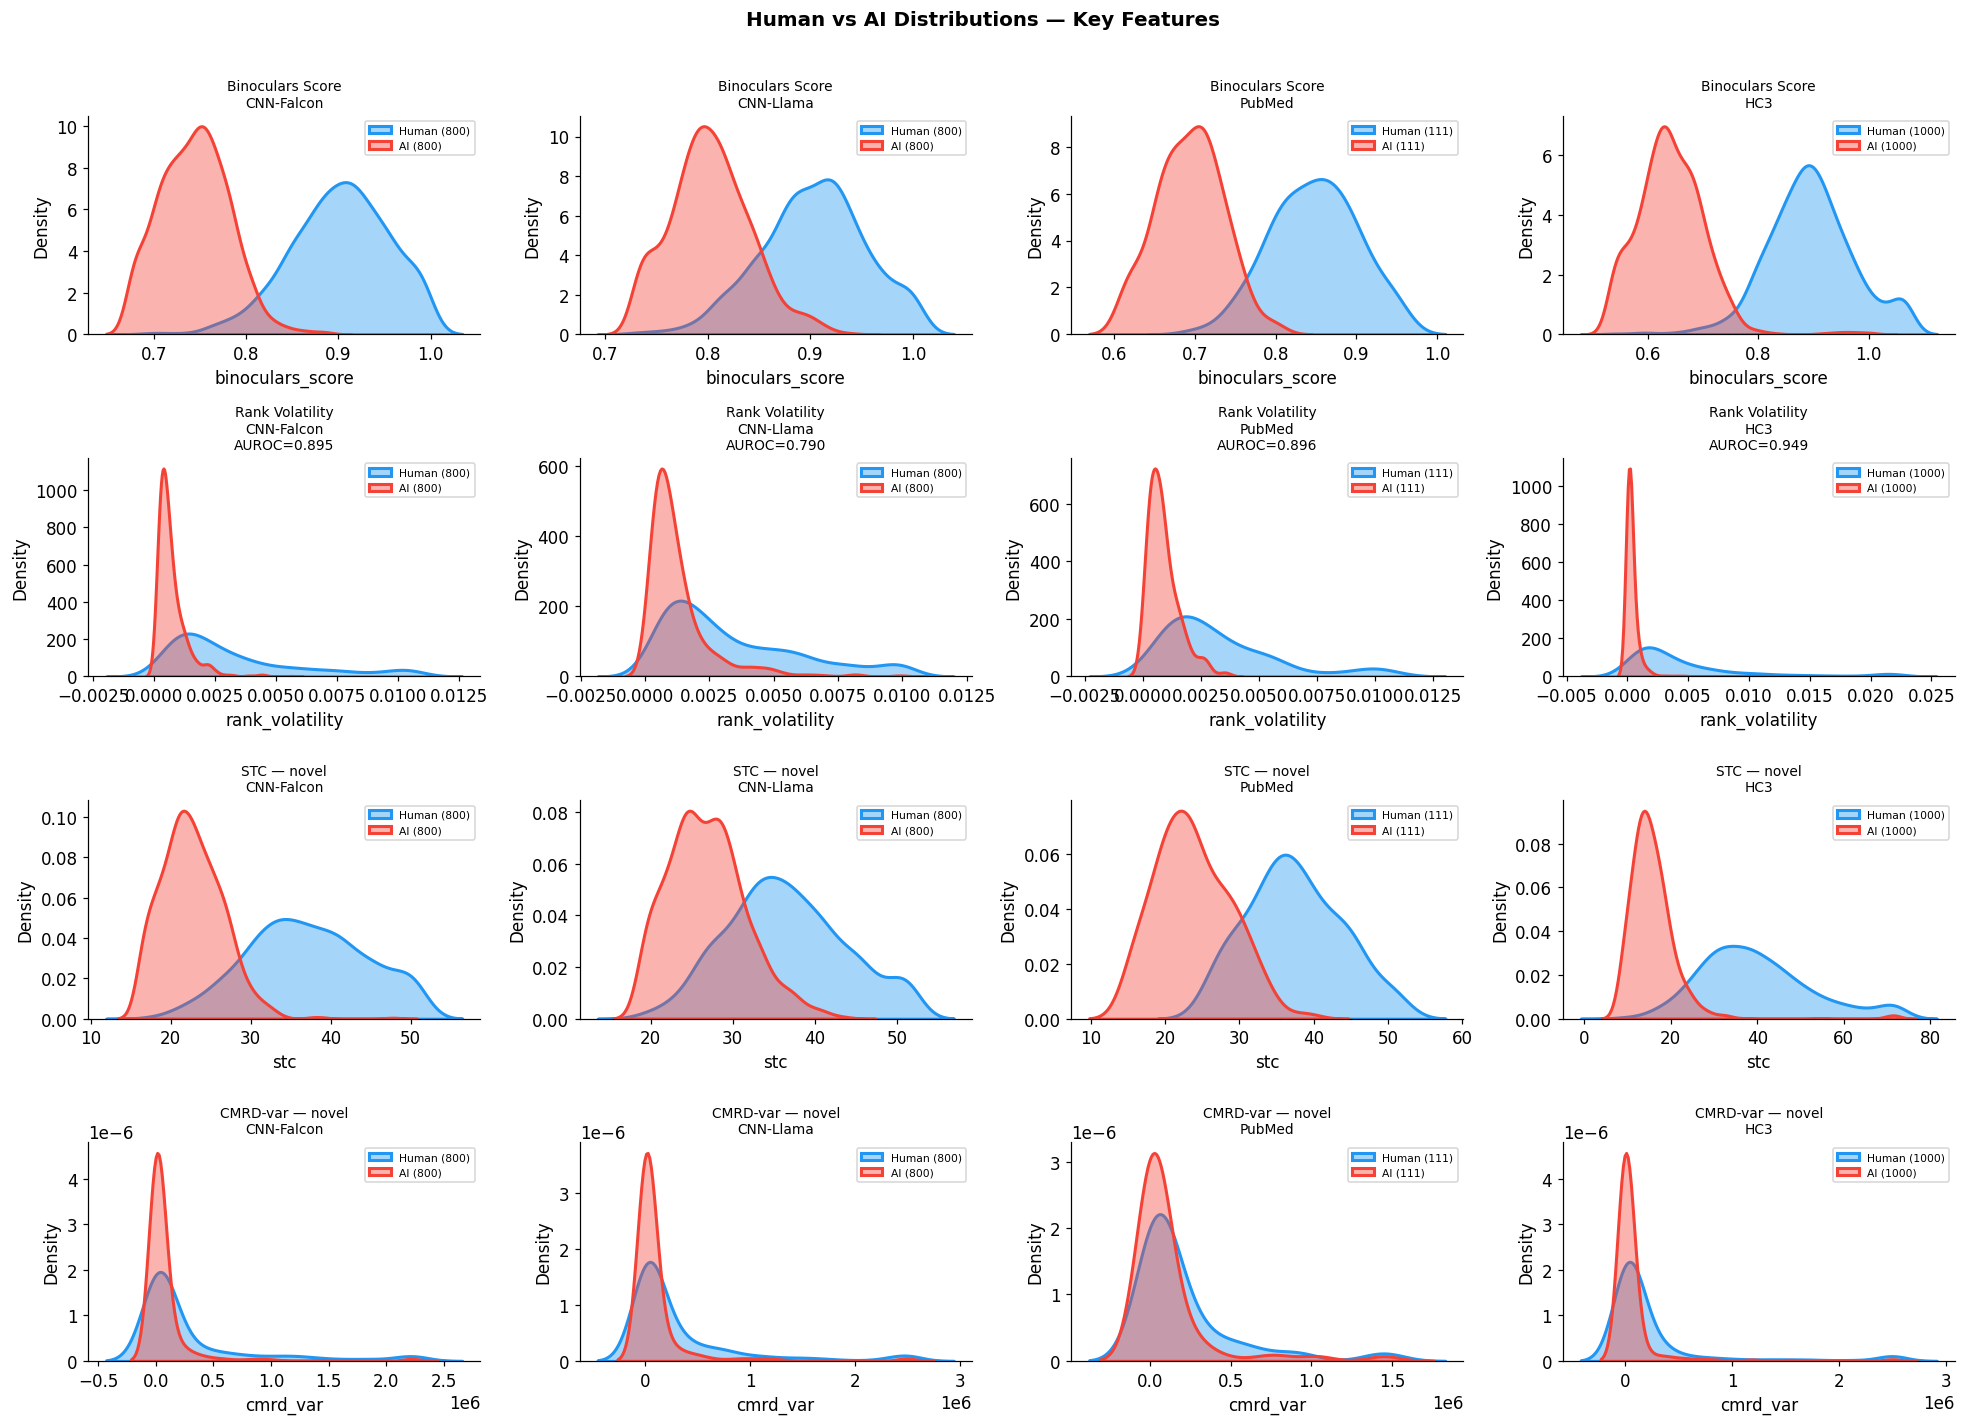

Fig 2 saved.


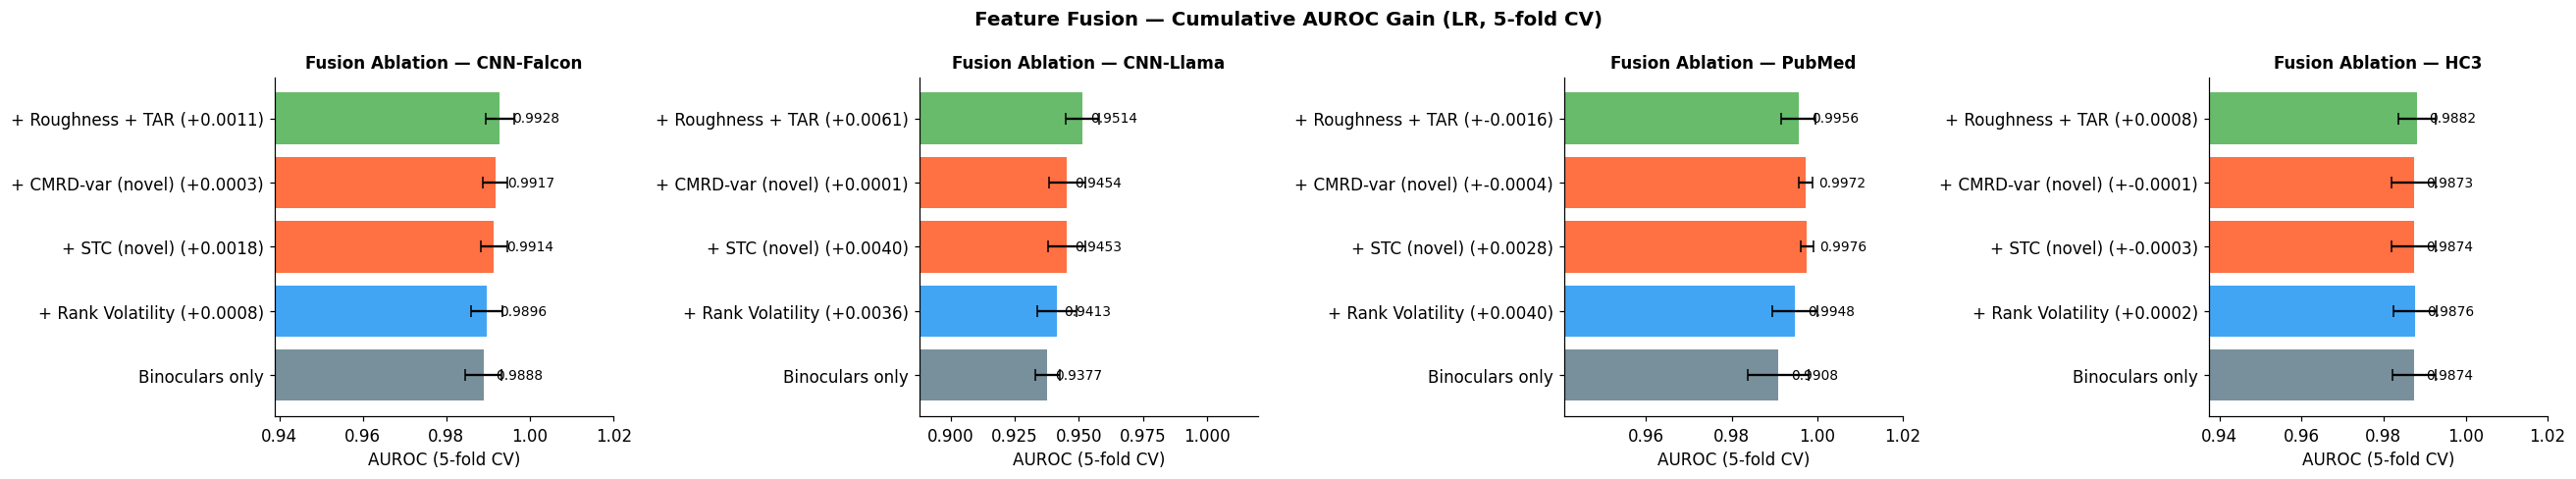

Fig 3 saved.


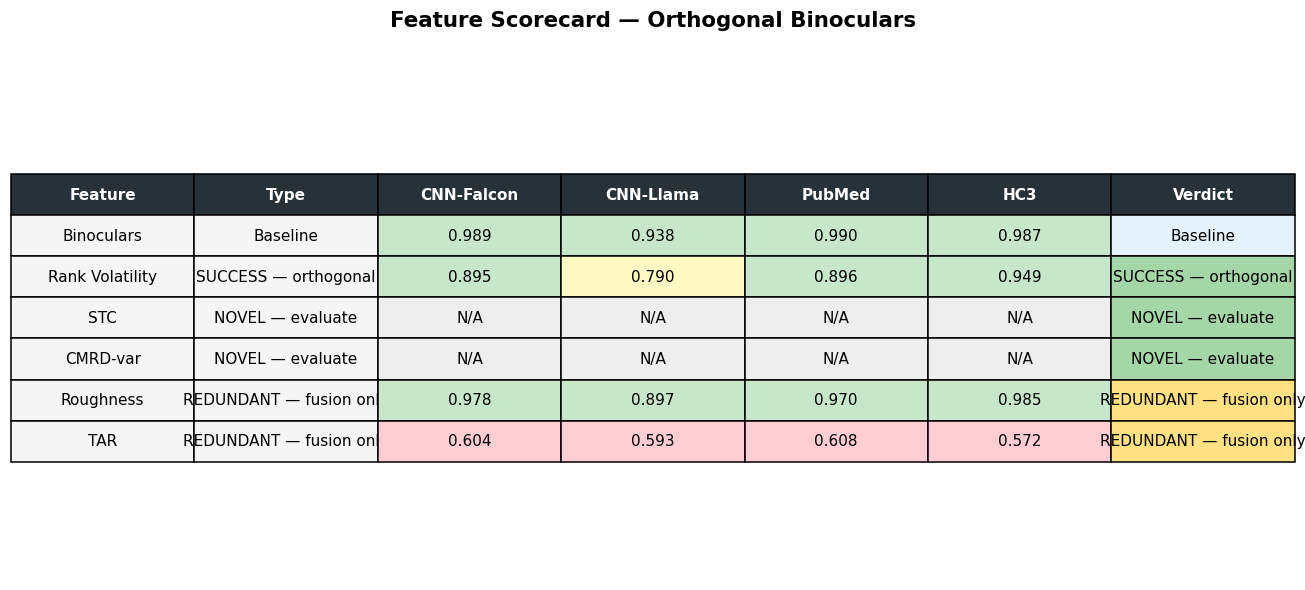

Fig 4 saved.
  ⏱  [█████████████████████░░░░░░░░░░░] 6.01h elapsed | 2.99h left  ALL DONE  [OK]

  OUTPUT FILES
  auroc_pivot.csv                                 0 KB
  fig1_auroc_roc.png                            212 KB
  fig2_kde.png                                  301 KB
  fig3_fusion.png                                78 KB
  fig4_scorecard.png                             72 KB
  metrics.csv                                     2 KB

  FEATURE VERDICT SUMMARY:
  Binoculars              avg AUROC=0.9759  [STRONG]
  Rank Volatility         avg AUROC=0.8825  [STRONG]
  STC (novel)             avg AUROC=0.9403  [STRONG]
  CMRD-var (novel)        avg AUROC=0.7092  [GOOD]
  Roughness               avg AUROC=0.9576  [STRONG]
  TAR                     avg AUROC=0.5940  [WEAK]

Pipeline complete.


In [8]:
budget("starting visualizations")

# ─── Figure 1: Master Dashboard ────────────────────────────────────────────────
# Layout: AUROC heatmap | ROC curves | Fusion ablation bar
# One figure that tells the whole story at a glance.

if METRICS.empty or len(RESULTS) == 0:
    print("No data to visualise.")
else:
    ds_list   = list(RESULTS.keys())
    n_ds      = len(ds_list)
    feat_cols = [(col, name, col_) for col, name, col_ in FEAT_REGISTRY]

    # ─────────────────────────────────────────────────────────────────────────
    # FIG 1 — AUROC Heatmap + ROC curves (one column per dataset)
    # ─────────────────────────────────────────────────────────────────────────
    fig1, axes1 = plt.subplots(
        1, n_ds + 1,
        figsize=(5.5 * n_ds + 5, 5.5),
        gridspec_kw={"width_ratios": [4] + [3]*n_ds}
    )

    # Left: AUROC heatmap
    ax_hm = axes1[0]
    if not METRICS.empty:
        pv = METRICS.pivot_table(index="feature", columns="dataset", values="auroc")
        # reorder rows by mean AUROC descending
        pv = pv.loc[pv.mean(axis=1).sort_values(ascending=False).index]
        sns.heatmap(pv.astype(float), ax=ax_hm, annot=True, fmt=".3f",
                    cmap="RdYlGn", vmin=0.5, vmax=1.0, linewidths=0.5,
                    cbar_kws={"shrink": 0.8, "label": "AUROC"})
        ax_hm.set_title("AUROC: Feature × Dataset", fontsize=12, fontweight="bold")
        ax_hm.set_xlabel(""); ax_hm.set_ylabel("")

    # Right: one ROC plot per dataset
    for di, ds_name in enumerate(ds_list):
        ax = axes1[di + 1]
        df_ = RESULTS[ds_name]
        ax.plot([0,1],[0,1], "k:", lw=1, alpha=0.3)

        for col, name, color in FEAT_REGISTRY:
            if col not in df_.columns: continue
            s = df_[col].values.astype(float)
            l = df_["label"].values.astype(int)
            ok = ~np.isnan(s); s, l = s[ok], l[ok]
            if len(np.unique(l)) < 2: continue

            au_t = roc_auc_score(l, -s)
            au_f = roc_auc_score(l,  s)
            flip = au_t >= au_f
            s4   = -s if flip else s
            auroc= max(au_t, au_f)

            fp, tp, _ = roc_curve(l, s4)
            lw = 2.5 if col in ("binoculars_score","rank_volatility","stc","cmrd_var") else 1.2
            ls = "-" if lw > 1.5 else "--"
            ax.plot(fp, tp, color=color, lw=lw, ls=ls,
                    label=f"{name} ({auroc:.3f})")

        ax.set_xlim(0,1); ax.set_ylim(0,1.01)
        ax.set_xlabel("FPR"); ax.set_ylabel("TPR")
        ax.set_title(f"ROC — {ds_name}", fontsize=11, fontweight="bold")
        ax.legend(fontsize=7.5, loc="lower right")

    plt.suptitle("Orthogonal Binoculars — Feature Detection Performance",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "fig1_auroc_roc.png"),
                bbox_inches="tight", dpi=110)
    plt.show()
    print("Fig 1 saved.")


    # ─────────────────────────────────────────────────────────────────────────
    # FIG 2 — KDE distributions (key features × datasets)
    # Shows separation between Human and AI distributions
    # ─────────────────────────────────────────────────────────────────────────
    KEY_FEATS = [("binoculars_score","Binoculars Score"),
                 ("rank_volatility","Rank Volatility"),
                 ("stc","STC — novel"),
                 ("cmrd_var","CMRD-var — novel")]

    fig2, axes2 = plt.subplots(len(KEY_FEATS), n_ds,
                                figsize=(4.5*n_ds, 3.2*len(KEY_FEATS)),
                                squeeze=False)

    for fi, (col, label) in enumerate(KEY_FEATS):
        for di, ds_name in enumerate(ds_list):
            ax = axes2[fi][di]
            df_ = RESULTS[ds_name]
            if col not in df_.columns:
                ax.text(0.5,0.5,"N/A",ha="center",va="center",
                        transform=ax.transAxes); continue

            h = df_[df_["label"]==0][col].values.astype(float)
            a = df_[df_["label"]==1][col].values.astype(float)
            h = h[~np.isnan(h)]; a = a[~np.isnan(a)]

            # clip to 2nd-98th for display
            all_ = np.concatenate([h, a])
            if len(all_) > 0:
                lo, hi = np.percentile(all_, [2, 98])
                h = np.clip(h, lo, hi); a = np.clip(a, lo, hi)

            if len(h)>1: sns.kdeplot(h, ax=ax, color=C_HUMAN, fill=True,
                                      alpha=0.4, lw=2, label=f"Human ({len(h)})")
            if len(a)>1: sns.kdeplot(a, ax=ax, color=C_AI,    fill=True,
                                      alpha=0.4, lw=2, label=f"AI ({len(a)})")

            # AUROC annotation
            row_m = METRICS[(METRICS["dataset"]==ds_name) &
                             (METRICS["feature"]==label)]
            auc_str = ""
            if not row_m.empty:
                auc = row_m["auroc"].values[0]
                if not np.isnan(auc):
                    auc_str = f"\nAUROC={auc:.3f}"

            ax.set_title(f"{label}\n{ds_name}{auc_str}", fontsize=9)
            ax.set_ylabel("Density"); ax.set_xlabel(col)
            ax.legend(fontsize=7)

    plt.suptitle("Human vs AI Distributions — Key Features",
                 fontsize=13, fontweight="bold", y=1.01)
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "fig2_kde.png"),
                bbox_inches="tight", dpi=110)
    plt.show()
    print("Fig 2 saved.")


    # ─────────────────────────────────────────────────────────────────────────
    # FIG 3 — Fusion Ablation: additive AUROC gain per feature group
    # ─────────────────────────────────────────────────────────────────────────
    FUSION_GROUPS = [
        ("Binoculars only",         ["binoculars_score"]),
        ("+ Rank Volatility",       ["binoculars_score","rank_volatility"]),
        ("+ STC (novel)",           ["binoculars_score","rank_volatility","stc"]),
        ("+ CMRD-var (novel)",      ["binoculars_score","rank_volatility","stc","cmrd_var"]),
        ("+ Roughness + TAR",       ["binoculars_score","rank_volatility","stc","cmrd_var",
                                     "roughness","tar"]),
    ]

    fig3, axes3 = plt.subplots(1, n_ds, figsize=(6*n_ds, 4.5), squeeze=False)

    for di, ds_name in enumerate(ds_list):
        ax   = axes3[0][di]
        df_  = RESULTS[ds_name]
        y    = df_["label"].values.astype(int)
        names, means, errs, colors_ = [], [], [], []
        prev_auc = None

        for gname, feat_cols_ in FUSION_GROUPS:
            avail = [c for c in feat_cols_ if c in df_.columns]
            if not avail: continue
            X = df_[avail].values.astype(float)
            ok = ~np.isnan(X).any(axis=1)
            Xv, yv = X[ok], y[ok]
            if len(np.unique(yv)) < 2 or len(yv) < 8: continue

            try:
                cv = cross_val_score(
                    LogisticRegression(max_iter=2000, class_weight="balanced"),
                    StandardScaler().fit_transform(Xv), yv,
                    cv=StratifiedKFold(5, shuffle=True, random_state=42),
                    scoring="roc_auc"
                )
                mu, sd = float(cv.mean()), float(cv.std())
            except Exception:
                continue

            delta = f" (+{mu-prev_auc:.4f})" if prev_auc is not None else ""
            names.append(gname + delta)
            means.append(mu); errs.append(sd)
            c_ = "#FF5722" if "novel" in gname.lower() else \
                 "#4CAF50" if gname == FUSION_GROUPS[-1][0] else \
                 "#607D8B" if "only" in gname else "#2196F3"
            colors_.append(c_)
            prev_auc = mu

        if not names: continue
        bars = ax.barh(names, means, xerr=errs, color=colors_,
                       alpha=0.85, capsize=4)
        ax.set_xlim(max(0, min(means)-0.05), 1.02)
        ax.axvline(0.5, color="grey", ls="--", lw=1, alpha=0.4)
        ax.set_xlabel("AUROC (5-fold CV)")
        ax.set_title(f"Fusion Ablation — {ds_name}", fontsize=11, fontweight="bold")
        for bar, val in zip(bars, means):
            ax.text(val+0.003, bar.get_y()+bar.get_height()/2,
                    f"{val:.4f}", va="center", fontsize=9)

    plt.suptitle("Feature Fusion — Cumulative AUROC Gain (LR, 5-fold CV)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "fig3_fusion.png"),
                bbox_inches="tight", dpi=110)
    plt.show()
    print("Fig 3 saved.")


    # ─────────────────────────────────────────────────────────────────────────
    # FIG 4 — Final Verdict: Feature scorecard (easy to read for anyone)
    # ─────────────────────────────────────────────────────────────────────────
    fig4, ax4 = plt.subplots(figsize=(12, 5.5))
    ax4.axis("off")

    # Build scorecard table
    sc_cols  = ["Feature", "Type"] + ds_list + ["Verdict"]
    sc_rows  = []

    verdict_map = [
        ("binoculars_score", "Binoculars",     "Baseline"),
        ("rank_volatility",  "Rank Volatility","SUCCESS — orthogonal"),
        ("stc",              "STC",            "NOVEL — evaluate"),
        ("cmrd_var",         "CMRD-var",       "NOVEL — evaluate"),
        ("roughness",        "Roughness",      "REDUNDANT — fusion only"),
        ("tar",              "TAR",            "REDUNDANT — fusion only"),
    ]

    cell_text  = []
    cell_color = []
    for col, name, typ in verdict_map:
        row_vals = [name, typ]
        row_col  = ["#F5F5F5", "#F5F5F5"]
        avg_auc  = []
        for ds_name in ds_list:
            sub = METRICS[(METRICS["dataset"]==ds_name) &
                          (METRICS["feature"]==name)]
            if sub.empty:
                row_vals.append("N/A"); row_col.append("#EEEEEE")
            else:
                auc = sub["auroc"].values[0]
                row_vals.append(f"{auc:.3f}" if not np.isnan(auc) else "N/A")
                c_ = "#C8E6C9" if auc>=0.85 else \
                     "#FFF9C4" if auc>=0.70 else \
                     "#FFCDD2" if not np.isnan(auc) else "#EEEEEE"
                row_col.append(c_)
                if not np.isnan(auc): avg_auc.append(auc)

        verdict = typ
        row_vals.append(verdict)
        v_col = "#A5D6A7" if "SUCCESS" in typ or "NOVEL" in typ else \
                "#FFE082" if "REDUNDANT" in typ else "#E3F2FD"
        row_col.append(v_col)
        cell_text.append(row_vals)
        cell_color.append(row_col)

    tbl = ax4.table(cellText=cell_text, colLabels=sc_cols,
                    cellColours=cell_color,
                    cellLoc="center", loc="center")
    tbl.auto_set_font_size(False)
    tbl.set_fontsize(10)
    tbl.scale(1, 2.0)

    # Style header
    for j in range(len(sc_cols)):
        tbl[(0, j)].set_facecolor("#263238")
        tbl[(0, j)].get_text().set_color("white")
        tbl[(0, j)].get_text().set_fontweight("bold")

    ax4.set_title("Feature Scorecard — Orthogonal Binoculars",
                  fontsize=14, fontweight="bold", pad=20)

    plt.tight_layout()
    plt.savefig(os.path.join(OUT_DIR, "fig4_scorecard.png"),
                bbox_inches="tight", dpi=110)
    plt.show()
    print("Fig 4 saved.")


# ─── Final output inventory ───────────────────────────────────────────────────
budget("ALL DONE")
print("\n" + "=" * 60)
print("  OUTPUT FILES")
print("=" * 60)
for fname in sorted(os.listdir(OUT_DIR)):
    if fname.endswith((".csv", ".png")):
        p   = os.path.join(OUT_DIR, fname)
        kb  = os.path.getsize(p) / 1024
        print(f"  {fname:<40}  {kb:>7.0f} KB")

print("\n  FEATURE VERDICT SUMMARY:")
if not METRICS.empty:
    for col, name, _ in FEAT_REGISTRY:
        sub = METRICS[METRICS["feature"]==name]
        if sub.empty: continue
        avg = sub["auroc"].mean()
        badge = "STRONG" if avg>=0.85 else "GOOD" if avg>=0.70 else "WEAK"
        print(f"  {name:<22}  avg AUROC={avg:.4f}  [{badge}]")

print("\nPipeline complete.")
